# Baseline v3 — Configurable FILTER + Band-Split BiLSTM (21 nhãn)

Một notebook duy nhất cho các experiment `mixture | oracle | filtered`, pretrain FILTER, adaptive gain, class weighting, sliding-window, fusion và band ablation.

- `oracle`: classifier đọc trực tiếp `oracle_noise` để đo upper bound của FILTER.
- `mixture`: classifier đọc mixture, không sử dụng FILTER.
- `filtered`: mixture → complex noise mask → estimated noise → classifier.
- Mỗi cấu hình có tên experiment, hash và thư mục checkpoint riêng.


## 1. Import và hằng số


In [1]:
import ast
import hashlib
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from sklearn.metrics import average_precision_score, f1_score
from torch.utils.data import DataLoader, Dataset


SELECTED = [137, 300, 0, 72, 138, 111, 307, 73, 288, 396, 98,
            195, 506, 329, 343, 164, 99, 328, 189, 335, 161]
SR, CLIP_S = 16_000, 5.0
N_FFT, WIN, HOP, N_MELS = 512, 512, 160, 64


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, precision_recall_fscore_support
from IPython.display import display


def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## 2. Cấu hình Kaggle

Chỉ cần chỉnh cell này khi muốn thay batch size, số epoch hoặc đường dẫn.


In [2]:
CONFIG = {
    # =========================
    # SYSTEM
    # =========================
    "seed": 2026,

    "data_root":
        "/kaggle/input/datasets/truongvp/21-labels/21_labels_dataset",

    "output_dir":
        "/kaggle/working/runs/baseline_v3",

    # =========================
    # TRAINING
    # =========================
    "epochs": 80,
    "batch_size": 16,
    "workers": 2,

    "learning_rate": 3e-4,

    # FILTER reconstruction contribution
    "lambda_filter": 1.0,

    # =========================
    # INPUT PIPELINE
    # =========================

    # Mixture -> FILTER -> Estimated Noise -> Classifier
    "input_mode": "filtered",

    # =========================
    # FILTER PRETRAINING
    # =========================

    # Train FILTER against oracle_noise first
    "pretrain_filter": True,

    # Longer than old 5 epochs
    "filter_pretrain_epochs": 20,

    # Freeze FILTER first while classifier learns
    "classifier_warmup_epochs": 5,

    # =========================
    # ADAPTIVE NOISE GAIN
    # =========================

    "adaptive_gain": True,

    # Avoid excessive amplification
    "gain_max_db": 12.0,

    # =========================
    # CLASS IMBALANCE
    # =========================

    # sqrt is safer than raw weights up to 20
    "pos_weight_mode": "sqrt",

    # =========================
    # EVALUATION
    # =========================

    # Full clip -> 5 s windows -> average probabilities
    "sliding_window_eval": True,

    "sliding_hop_seconds": 2.5,

    # =========================
    # FREQUENCY FUSION
    # =========================

    # Cross-band adaptive weighting
    "fusion": "gating",

    # Low / Mid / High
    "band_mode": "3band",

    # =========================
    # EARLY STOPPING
    # =========================

    "early_stopping_patience": 8,
}
assert CONFIG["input_mode"] in {"oracle", "filtered", "mixture"}
assert CONFIG["pos_weight_mode"] in {"raw", "sqrt", "none"}
assert CONFIG["fusion"] in {"gating", "mean", "concat"}
assert CONFIG["band_mode"] in {"full", "2band", "3band"}
if CONFIG["pretrain_filter"] and CONFIG["input_mode"] != "filtered":
    raise ValueError("pretrain_filter chi co y nghia voi input_mode='filtered'")
parts = [CONFIG["input_mode"], CONFIG["band_mode"], CONFIG["fusion"],
         f"pw-{CONFIG['pos_weight_mode']}",
         "gain" if CONFIG["adaptive_gain"] else "nogain",
         "slide" if CONFIG["sliding_window_eval"] else "center",
         "pretrain" if CONFIG["pretrain_filter"] else "nopretrain"]
config_for_hash = {k: v for k, v in CONFIG.items() if k not in {"output_dir", "experiment_name"}}
config_hash = hashlib.sha1(json.dumps(config_for_hash, sort_keys=True).encode()).hexdigest()[:8]
CONFIG["experiment_name"] = "_".join(parts + [config_hash])
CONFIG["output_dir"] = str(Path(CONFIG["output_dir"]) / CONFIG["experiment_name"])

seed_all(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
print("Experiment:", CONFIG["experiment_name"])
print("Classifier input:", CONFIG["input_mode"])
print("Output dir:", CONFIG["output_dir"])
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
Device : cuda
Experiment: filtered_3band_gating_pw-sqrt_gain_slide_pretrain_96538d25
Classifier input: filtered
Output dir: /kaggle/working/runs/baseline_v3/filtered_3band_gating_pw-sqrt_gain_slide_pretrain_96538d25
GPU    : Tesla T4


## 3. Kiểm tra dataset và danh sách 21 nhãn


In [3]:
DATA_ROOT = Path(CONFIG["data_root"])
if not DATA_ROOT.is_dir():
    fallback = Path("/kaggle/input/21-labels/21_labels_dataset")
    if fallback.is_dir():
        DATA_ROOT = fallback
assert DATA_ROOT.is_dir(), (
    f"Không tìm thấy dataset tại {CONFIG['data_root']}. "
    "Hãy kiểm tra đường dẫn trong Kaggle Data panel."
)

required = [
    DATA_ROOT / split / "manifest.csv"
    for split in ("train_single", "validation_single", "test_single")
]
missing = [str(path) for path in required if not path.is_file()]
assert not missing, "Thiếu manifest: " + ", ".join(missing)

label_info = pd.read_csv(DATA_ROOT / "selected_labels.csv").sort_values("model_index")
CLASS_NAMES = label_info["display_name"].tolist()
display(label_info[["model_index", "original_index", "display_name"]])

rows = []
for split in ("train_single", "validation_single", "test_single"):
    frame = pd.read_csv(DATA_ROOT / split / "manifest.csv")
    rows.append({
        "split": split,
        "samples": len(frame),
        "mixture_wav": len(list((DATA_ROOT / split / "mixture").glob("*.wav"))),
        "oracle_noise_wav": len(list((DATA_ROOT / split / "oracle_noise").glob("*.wav"))),
    })
display(pd.DataFrame(rows))
print("Dataset:", DATA_ROOT)


,model_index,original_index,display_name
0,0,137,Music
1,1,300,Vehicle
2,2,0,Speech
3,3,72,Animal
4,4,138,Musical instrument
5,5,111,Bird
6,6,307,Car
7,7,73,"Domestic animals, pets"
8,8,288,Water
9,9,396,Siren


,split,samples,mixture_wav,oracle_noise_wav
0,train_single,18231,18231,18231
1,validation_single,3907,3907,3907
2,test_single,3906,3906,3906


Dataset: /kaggle/input/datasets/truongvp/21-labels/21_labels_dataset


## 4. Dataset và xử lý waveform


In [4]:
def parse_labels(value) -> list[int]:
    if not isinstance(value, str):
        return []
    try:
        return [int(v) for v in ast.literal_eval(value)]
    except (ValueError, SyntaxError, TypeError):
        return [int(v) for v in value.strip("[]() ").split(",") if v.strip()]


def read_mono(path: Path) -> torch.Tensor:
    x, sr = sf.read(path, dtype="float32", always_2d=True)
    x = torch.from_numpy(x.mean(axis=1))
    return torchaudio.functional.resample(x, sr, SR) if sr != SR else x


def crop_or_pad(x: torch.Tensor, length: int, start: int) -> torch.Tensor:
    x = x[start:start + length]
    return F.pad(x, (0, max(0, length - x.numel())))[:length]


class NoiseDataset(Dataset):
    def __init__(self, root: Path, split: str, train: bool):
        self.root, self.train = root / split, train
        self.df = pd.read_csv(self.root / "manifest.csv")
        self.length = int(CLIP_S * SR)
        self.label_pos = {label: i for i, label in enumerate(SELECTED)}

    def __len__(self): return len(self.df)

    def load_full(self, i):
        row = self.df.iloc[i]
        sid = row.sample_id
        mix = read_mono(self.root / "mixture" / f"{sid}.wav")
        noise = read_mono(self.root / "oracle_noise" / f"{sid}.wav")
        available = min(mix.numel(), noise.numel())
        mix, noise = mix[:available], noise[:available]
        target = torch.zeros(len(SELECTED))
        for label in parse_labels(row.label_indices):
            if label in self.label_pos:
                target[self.label_pos[label]] = 1.0
        return mix, noise, target, float(row.target_snr_db)

    def __getitem__(self, i):
        mix, noise, target, snr = self.load_full(i)
        available = min(mix.numel(), noise.numel())
        start = (random.randint(0, max(0, available - self.length)) if self.train
                 else max(0, (available - self.length) // 2))
        mix = crop_or_pad(mix, self.length, start)
        noise = crop_or_pad(noise, self.length, start)
        return mix, noise, target, snr




## 5. DataLoader và cân bằng nhãn


In [5]:
train_ds = NoiseDataset(DATA_ROOT, "train_single", True)
val_ds = NoiseDataset(DATA_ROOT, "validation_single", False)
test_ds = NoiseDataset(DATA_ROOT, "test_single", False)

loader_args = dict(
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["workers"],
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=CONFIG["workers"] > 0,
)
train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_args)
val_loader = DataLoader(val_ds, shuffle=False, **loader_args)
test_loader = DataLoader(test_ds, shuffle=False, **loader_args)

# Tính pos_weight trực tiếp từ manifest, không cần giải mã WAV.
label_matrix = np.zeros((len(train_ds), len(SELECTED)), dtype=np.float32)
for row_i, value in enumerate(train_ds.df["label_indices"]):
    for label in parse_labels(value):
        if label in train_ds.label_pos:
            label_matrix[row_i, train_ds.label_pos[label]] = 1.0
positives = label_matrix.sum(0)
raw_pos_weight = torch.tensor(
    (len(train_ds) - positives) / np.maximum(positives, 1),
    dtype=torch.float32, device=DEVICE,
).clamp(max=20)
if CONFIG["pos_weight_mode"] == "raw":
    pos_weight = raw_pos_weight
elif CONFIG["pos_weight_mode"] == "sqrt":
    pos_weight = raw_pos_weight.sqrt()
else:
    pos_weight = None
effective_pos_weight = (pos_weight.cpu().numpy() if pos_weight is not None
                        else np.ones(len(SELECTED), dtype=np.float32))

distribution = pd.DataFrame({
    "label": CLASS_NAMES,
    "train_positive": positives.astype(int),
    "positive_%": np.round(100 * positives / len(train_ds), 2),
    "raw_pos_weight": np.round(raw_pos_weight.cpu().numpy(), 2),
    "effective_pos_weight": np.round(effective_pos_weight, 2),
})
display(distribution)
print(f"Train: {len(train_ds):,} clips / {len(train_loader):,} batches")
print(f"Val  : {len(val_ds):,} clips")
print(f"Test : {len(test_ds):,} clips")


,label,train_positive,positive_%,raw_pos_weight,effective_pos_weight
0,Music,4149,22.76,3.390000,1.84
1,Vehicle,2449,13.43,6.440000,2.54
2,Speech,1918,10.52,8.510000,2.92
3,Animal,1834,10.06,8.940000,2.99
4,Musical instrument,1412,7.75,11.910000,3.45
5,Bird,1140,6.25,14.990000,3.87
6,Car,1086,5.96,15.790000,3.97
7,"Domestic animals, pets",1033,5.67,16.650000,4.08
8,Water,944,5.18,18.309999,4.28
9,Siren,933,5.12,18.540001,4.31


Train: 18,231 clips / 1,139 batches
Val  : 3,907 clips
Test : 3,906 clips


## 6. Kiến trúc FILTER + Band-Split Classifier


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(cout), nn.SiLU(),
                                 nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(cout), nn.SiLU())
    def forward(self, x): return self.net(x)


class NoiseMaskUNet(nn.Module):
    """Small U-Net predicting a bounded complex ratio mask."""
    def __init__(self):
        super().__init__()
        self.e1, self.e2, self.e3 = ConvBlock(2, 16), ConvBlock(16, 32), ConvBlock(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2, self.d2 = nn.ConvTranspose2d(64, 32, 2, 2), ConvBlock(64, 32)
        self.up1, self.d1 = nn.ConvTranspose2d(32, 16, 2, 2), ConvBlock(32, 16)
        self.out = nn.Conv2d(16, 2, 1)

    @staticmethod
    def _fit(x, ref):
        return F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)

    def forward(self, x):
        a = self.e1(x); b = self.e2(self.pool(a)); z = self.e3(self.pool(b))
        z = self.d2(torch.cat([self._fit(self.up2(z), b), b], 1))
        z = self.d1(torch.cat([self._fit(self.up1(z), a), a], 1))
        return torch.tanh(self.out(z))


class BandEncoder(nn.Module):
    def __init__(self, hidden=64, emb=128):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(1, 16), nn.MaxPool2d((1, 2)),
            ConvBlock(16, 32), nn.MaxPool2d((1, 2)),
            nn.AdaptiveAvgPool2d((4, None)))
        self.rnn = nn.LSTM(32 * 4, hidden, batch_first=True, bidirectional=True)
        self.att = nn.Linear(hidden * 2, 1)
        self.proj = nn.Sequential(nn.Dropout(.2), nn.Linear(hidden * 2, emb))

    def forward(self, x):
        x = self.cnn(x).permute(0, 3, 1, 2).flatten(2)
        x, _ = self.rnn(x)
        x = (torch.softmax(self.att(x), 1) * x).sum(1)
        return self.proj(x)


BAND_LAYOUTS = {
    "full": ((0, 64),),
    "2band": ((0, 40), (32, 64)),       # overlap 8 mel bins
    "3band": ((0, 32), (32, 49), (49, 64)),
}


class BaselineV3(nn.Module):
    def __init__(self, n_classes=21, band_mode="3band", fusion="gating",
                 adaptive_gain=False, gain_max_db=12.0):
        super().__init__()
        self.fusion = fusion
        self.adaptive_gain = adaptive_gain
        self.gain_max = 10.0 ** (gain_max_db / 20.0)
        self.register_buffer("window", torch.hann_window(WIN), persistent=False)
        self.filter = NoiseMaskUNet()
        self.mel = torchaudio.transforms.MelScale(N_MELS, SR, 20, SR // 2, N_FFT // 2 + 1,
                                                   mel_scale="htk")
        self.bands = BAND_LAYOUTS[band_mode]
        self.encoders = nn.ModuleList(BandEncoder() for _ in self.bands)
        self.gate = nn.Linear(128 * len(self.bands), len(self.bands))
        head_dim = 128 * len(self.bands) if fusion == "concat" else 128
        self.head = nn.Linear(head_dim, n_classes)

    def stft(self, x):
        return torch.stft(x, N_FFT, HOP, WIN, self.window, return_complex=True)

    def estimate_noise(self, mixture):
        mixture_spec = self.stft(mixture)
        mask_ri = self.filter(torch.view_as_real(mixture_spec).permute(0, 3, 1, 2))
        mask = torch.complex(mask_ri[:, 0], mask_ri[:, 1])
        return mask * mixture_spec, mask, mixture_spec

    def apply_adaptive_gain(self, noise_spec, mixture_spec):
        if not self.adaptive_gain:
            return noise_spec
        # Nang noise yeu ve gan RMS pho cua mixture, nhung gioi han gain.
        # detach tranh tao duong tat gradient khuyen khich FILTER giam nang luong.
        dims = tuple(range(1, noise_spec.ndim))
        noise_rms = noise_spec.abs().square().mean(dims, keepdim=True).sqrt()
        mix_rms = mixture_spec.abs().square().mean(dims, keepdim=True).sqrt()
        gain = (mix_rms / (noise_rms + 1e-8)).clamp(1.0, self.gain_max).detach()
        return noise_spec * gain

    def forward(self, mixture, oracle=None, input_mode="filtered"):
        if input_mode == "filtered":
            raw_estimate, mask, mixture_spec = self.estimate_noise(mixture)
            classifier_spec = self.apply_adaptive_gain(raw_estimate, mixture_spec)
            reconstruction_spec = raw_estimate
        elif input_mode == "oracle":
            if oracle is None:
                raise ValueError("oracle waveform is required for input_mode='oracle'")
            classifier_spec, mask = self.stft(oracle), None
            reconstruction_spec = classifier_spec
        elif input_mode == "mixture":
            classifier_spec, mask = self.stft(mixture), None
            reconstruction_spec = classifier_spec
        else:
            raise ValueError(f"Unknown input_mode: {input_mode}")
        # MelScale la matmul nen autocast ep xuong fp16: |X|^2 sau adaptive gain
        # tran 65504 -> inf -> BatchNorm sinh NaN. Giu khoi nay o fp32.
        with torch.autocast(classifier_spec.device.type, enabled=False):
            power = classifier_spec.abs().square().float()
            mel = torch.log(self.mel(power) + 1e-6).unsqueeze(1)
        emb = [enc(mel[:, :, lo:hi]) for enc, (lo, hi) in zip(self.encoders, self.bands)]
        if self.fusion == "gating":
            weights = torch.softmax(self.gate(torch.cat(emb, 1)), 1)
            fused = sum(weights[:, i:i + 1] * value for i, value in enumerate(emb))
        elif self.fusion == "mean":
            weights = mel.new_full((mel.shape[0], len(emb)), 1.0 / len(emb))
            fused = torch.stack(emb, 1).mean(1)
        else:  # concat
            weights = mel.new_full((mel.shape[0], len(emb)), 1.0 / len(emb))
            fused = torch.cat(emb, 1)
        return self.head(fused), reconstruction_spec, mask, weights




## 7. Loss và hàm đánh giá


In [7]:
def filter_reconstruction_loss(estimate, oracle_spec):
    complex_l1 = (torch.view_as_real(estimate) - torch.view_as_real(oracle_spec)).abs().mean()
    logmag_l1 = (torch.log1p(estimate.abs()) - torch.log1p(oracle_spec.abs())).abs().mean()
    return complex_l1 + logmag_l1


def losses(model, mix, oracle, labels, pos_weight, lambda_filter, input_mode):
    logits, estimate, _, _ = model(mix, oracle, input_mode)
    if input_mode == "filtered":
        # Filter loss chi co nghia khi classifier dung FILTER(mixture).
        oracle_spec = model.stft(oracle)
        filter_loss = filter_reconstruction_loss(estimate, oracle_spec)
    else:
        filter_loss = estimate.real.new_zeros(())
    cls_loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight)
    filter_trainable = any(parameter.requires_grad for parameter in model.filter.parameters())
    total = cls_loss + (lambda_filter * filter_loss
                        if input_mode == "filtered" and filter_trainable else 0.0)
    return total, cls_loss, filter_loss


def make_paired_windows(mix, oracle, length, hop):
    available = min(mix.numel(), oracle.numel())
    if available <= length:
        return (crop_or_pad(mix, length, 0).unsqueeze(0),
                crop_or_pad(oracle, length, 0).unsqueeze(0))
    starts = list(range(0, available - length + 1, hop))
    if starts[-1] != available - length:
        starts.append(available - length)
    return (torch.stack([crop_or_pad(mix, length, s) for s in starts]),
            torch.stack([crop_or_pad(oracle, length, s) for s in starts]))


@torch.inference_mode()
def predict(model, loader, device, input_mode, sliding=False, hop_seconds=2.5):
    model.eval(); ys, ps, snrs = [], [], []
    if not sliding:
        for mix, oracle, y, snr in loader:
            logits, *_ = model(mix.to(device), oracle.to(device), input_mode)
            ys.append(y.numpy()); ps.append(logits.sigmoid().cpu().numpy()); snrs.append(snr.numpy())
    else:
        dataset = loader.dataset
        hop = max(1, int(hop_seconds * SR))
        for i in range(len(dataset)):
            mix, oracle, y, snr = dataset.load_full(i)
            mix_w, oracle_w = make_paired_windows(mix, oracle, dataset.length, hop)
            window_probs = []
            for start in range(0, len(mix_w), loader.batch_size):
                end = start + loader.batch_size
                logits, *_ = model(mix_w[start:end].to(device),
                                   oracle_w[start:end].to(device), input_mode)
                window_probs.append(logits.sigmoid().cpu())
            ys.append(y.numpy()[None]); ps.append(torch.cat(window_probs).mean(0).numpy()[None])
            snrs.append(np.asarray([snr]))
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(snrs)


def pretrain_filter_stage(model, loader, device, epochs, learning_rate, output_dir):
    optimizer = torch.optim.AdamW(model.filter.parameters(), lr=learning_rate, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    for epoch in range(1, epochs + 1):
        model.filter.train(); total_loss, seen = 0.0, 0
        for mix, oracle, _, _ in loader:
            mix, oracle = mix.to(device), oracle.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device.type, enabled=device.type == "cuda"):
                estimate, _, _ = model.estimate_noise(mix)
                loss = filter_reconstruction_loss(estimate, model.stft(oracle))
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.filter.parameters(), 5.0)
            scaler.step(optimizer); scaler.update()
            total_loss += loss.item() * len(mix); seen += len(mix)
        print(f"filter pretrain {epoch:02d}/{epochs} | loss {total_loss / seen:.5f}")
    torch.save(model.filter.state_dict(), output_dir / "pretrained_filter.pt")


def tune_thresholds(y, p):
    thresholds = np.full(y.shape[1], .5)
    for c in range(y.shape[1]):
        scores = [(f1_score(y[:, c], p[:, c] >= t, zero_division=0), t)
                  for t in np.arange(.10, .91, .05)]
        thresholds[c] = max(scores)[1]
    return thresholds


def metrics(y, p, thresholds):
    pred = p >= thresholds
    return {"macro_f1": float(f1_score(y, pred, average="macro", zero_division=0)),
            "micro_f1": float(f1_score(y, pred, average="micro", zero_division=0)),
            "mAP": float(average_precision_score(y, p, average="macro"))}




## 8. Khởi tạo mô hình


In [8]:
OUT_DIR = Path(CONFIG["output_dir"])
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf8")
model = BaselineV3(
    n_classes=len(SELECTED), band_mode=CONFIG["band_mode"],
    fusion=CONFIG["fusion"], adaptive_gain=CONFIG["adaptive_gain"],
    gain_max_db=CONFIG["gain_max_db"],
).to(DEVICE)
if CONFIG["pretrain_filter"]:
    pretrain_filter_stage(model, train_loader, DEVICE,
                          CONFIG["filter_pretrain_epochs"],
                          CONFIG["learning_rate"], OUT_DIR)
if CONFIG["input_mode"] != "filtered":
    # Oracle/mixture baseline khong dung FILTER.
    model.filter.requires_grad_(False)
elif CONFIG["pretrain_filter"] and CONFIG["classifier_warmup_epochs"] > 0:
    # Freeze FILTER de classifier hoc tren estimate da on dinh truoc joint fine-tune.
    model.filter.requires_grad_(False)
optimizer_parameters = (list(model.parameters()) if CONFIG["input_mode"] == "filtered"
                        else [p for p in model.parameters() if p.requires_grad])
optimizer = torch.optim.AdamW(
    optimizer_parameters,
    lr=CONFIG["learning_rate"],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.5
)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(model)


/tmp/ipykernel_23/1456418622.py:80: UserWarning: ComplexHalf support is experimental and many operators don't support it yet. (Triggered internally at /pytorch/aten/src/ATen/EmptyTensor.cpp:54.)
  mask = torch.complex(mask_ri[:, 0], mask_ri[:, 1])


filter pretrain 01/20 | loss 0.13208
filter pretrain 02/20 | loss 0.11015
filter pretrain 03/20 | loss 0.10542
filter pretrain 04/20 | loss 0.10306
filter pretrain 05/20 | loss 0.10122
filter pretrain 06/20 | loss 0.09980
filter pretrain 07/20 | loss 0.09870
filter pretrain 08/20 | loss 0.09784
filter pretrain 09/20 | loss 0.09714
filter pretrain 10/20 | loss 0.09674
filter pretrain 11/20 | loss 0.09598
filter pretrain 12/20 | loss 0.09561
filter pretrain 13/20 | loss 0.09513
filter pretrain 14/20 | loss 0.09482
filter pretrain 15/20 | loss 0.09452
filter pretrain 16/20 | loss 0.09404
filter pretrain 17/20 | loss 0.09398
filter pretrain 18/20 | loss 0.09359
filter pretrain 19/20 | loss 0.09345
filter pretrain 20/20 | loss 0.09320
Trainable parameters: 401,163
BaselineV3(
  (filter): NoiseMaskUNet(
    (e1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, a

## 9. Sanity check kích thước tensor


In [9]:
mix, oracle, labels, snr = next(iter(train_loader))
with torch.no_grad():
    logits, estimated_spec, mask, band_weights = model(
        mix[:2].to(DEVICE), oracle[:2].to(DEVICE), CONFIG["input_mode"]
    )
print("mixture       :", tuple(mix[:2].shape))
print("logits        :", tuple(logits.shape))
print("estimated STFT:", tuple(estimated_spec.shape))
print("complex mask  :", None if mask is None else tuple(mask.shape))
print("band weights  :", tuple(band_weights.shape))
print("sum gate/sample:", band_weights.sum(1).cpu().numpy())


mixture       : (2, 80000)
logits        : (2, 21)
estimated STFT: (2, 257, 501)
complex mask  : (2, 257, 501)
band weights  : (2, 3)
sum gate/sample: [1. 1.]


## 10. Training

Cell này lưu checkpoint tốt nhất vào `/kaggle/working/runs/baseline_v3/best.pt`.


In [10]:
history = []
best_f1, bad_epochs = -1.0, 0
history_path = OUT_DIR / "history.jsonl"
history_path.write_text("", encoding="utf8")

for epoch in range(1, CONFIG["epochs"] + 1):
    if (CONFIG["input_mode"] == "filtered" and CONFIG["pretrain_filter"]
            and epoch == CONFIG["classifier_warmup_epochs"] + 1):
        model.filter.requires_grad_(True)
        best_f1, bad_epochs = -1.0, 0  # joint phase co early stopping/checkpoint rieng
        print("Unfreeze FILTER: bat dau joint fine-tune")
    phase = ("classifier_warmup" if CONFIG["input_mode"] == "filtered"
             and not any(p.requires_grad for p in model.filter.parameters()) else "joint")
    model.train()
    if phase == "classifier_warmup":
        model.filter.eval()  # freeze ca BatchNorm running statistics
    sums = np.zeros(3)
    seen = 0
    started = time.time()

    for mix, oracle, target, _ in train_loader:
        mix = mix.to(DEVICE, non_blocking=True)
        oracle = oracle.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(DEVICE.type, enabled=DEVICE.type == "cuda"):
            total, cls_loss, filter_loss = losses(
                model, mix, oracle, target, pos_weight, CONFIG["lambda_filter"],
                CONFIG["input_mode"],
            )
        scaler.scale(total).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        batch_n = len(target)
        sums += np.array([total.item(), cls_loss.item(), filter_loss.item()]) * batch_n
        seen += batch_n

    val_y, val_prob, _ = predict(
        model, val_loader, DEVICE, CONFIG["input_mode"],
        sliding=CONFIG["sliding_window_eval"],
        hop_seconds=CONFIG["sliding_hop_seconds"],
    )
    assert np.isfinite(val_prob).all(), f"epoch {epoch}: val_prob co NaN/inf"
    thresholds = tune_thresholds(val_y, val_prob)
    val_metrics = metrics(val_y, val_prob, thresholds)
    scheduler.step(val_metrics["macro_f1"])

    record = {
        "epoch": epoch,
        "phase": phase,
        "train_total_loss": sums[0] / seen,
        "train_classification_loss": sums[1] / seen,
        "train_filter_loss": sums[2] / seen,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": optimizer.param_groups[0]["lr"],
        "seconds": time.time() - started,
    }
    history.append(record)
    with history_path.open("a", encoding="utf8") as stream:
        stream.write(json.dumps(record) + "\n")

    improved = val_metrics["macro_f1"] > best_f1 + 1e-3
    if improved:
        best_f1, bad_epochs = val_metrics["macro_f1"], 0
        torch.save({
            "model": model.state_dict(),
            "thresholds": thresholds,
            "selected_indices": SELECTED,
            "class_names": CLASS_NAMES,
            "config": CONFIG,
            "epoch": epoch,
            "val_metrics": val_metrics,
        }, OUT_DIR / "best.pt")
    else:
        bad_epochs += 1

    print(
        f"epoch {epoch:02d} [{phase}] | total {record['train_total_loss']:.4f} "
        f"| cls {record['train_classification_loss']:.4f} "
        f"| filter {record['train_filter_loss']:.4f} "
        f"| val F1 {val_metrics['macro_f1']:.4f} "
        f"| mAP {val_metrics['mAP']:.4f}"
        + ("  <- best" if improved else "")
    )
    if bad_epochs >= CONFIG["early_stopping_patience"]:
        print(f"Early stopping. Best val macro-F1: {best_f1:.4f}")
        break


epoch 01 [classifier_warmup] | total 0.5195 | cls 0.5195 | filter 0.0936 | val F1 0.2680 | mAP 0.1982  <- best
epoch 02 [classifier_warmup] | total 0.4766 | cls 0.4766 | filter 0.0935 | val F1 0.3036 | mAP 0.2334  <- best
epoch 03 [classifier_warmup] | total 0.4616 | cls 0.4616 | filter 0.0937 | val F1 0.3262 | mAP 0.2543  <- best
epoch 04 [classifier_warmup] | total 0.4524 | cls 0.4524 | filter 0.0938 | val F1 0.3278 | mAP 0.2625  <- best
epoch 05 [classifier_warmup] | total 0.4436 | cls 0.4436 | filter 0.0937 | val F1 0.3331 | mAP 0.2707  <- best
Unfreeze FILTER: bat dau joint fine-tune
epoch 06 [joint] | total 0.5367 | cls 0.4398 | filter 0.0970 | val F1 0.3474 | mAP 0.2880  <- best
epoch 07 [joint] | total 0.5299 | cls 0.4326 | filter 0.0973 | val F1 0.3477 | mAP 0.2913
epoch 08 [joint] | total 0.5238 | cls 0.4262 | filter 0.0976 | val F1 0.3609 | mAP 0.3083  <- best
epoch 09 [joint] | total 0.5182 | cls 0.4199 | filter 0.0983 | val F1 0.3707 | mAP 0.3136  <- best
epoch 10 [joint] 

## 11. Training curves


,epoch,phase,train_total_loss,train_classification_loss,train_filter_loss,val_macro_f1,val_micro_f1,val_mAP,lr,seconds
0,1,classifier_warmup,0.519501,0.519501,0.093563,0.268012,0.296885,0.198193,0.000300,301.772104
1,2,classifier_warmup,0.476608,0.476608,0.093531,0.303637,0.327863,0.233414,0.000300,150.948587
2,3,classifier_warmup,0.461562,0.461562,0.093652,0.326191,0.352830,0.254309,0.000300,150.099797
3,4,classifier_warmup,0.452355,0.452355,0.093817,0.327808,0.347841,0.262535,0.000300,150.752375
4,5,classifier_warmup,0.443598,0.443598,0.093697,0.333101,0.349839,0.270743,0.000300,150.774380
5,6,joint,0.536724,0.439752,0.096972,0.347353,0.373623,0.287988,0.000300,294.147630
6,7,joint,0.529944,0.432634,0.097309,0.347703,0.369696,0.291293,0.000300,293.870831
7,8,joint,0.523821,0.426247,0.097575,0.360873,0.390661,0.308282,0.000300,298.699609
8,9,joint,0.518158,0.419882,0.098276,0.370692,0.386184,0.313649,0.000300,299.836118
9,10,joint,0.511736,0.413444,0.098293,0.367127,0.391171,0.310406,0.000300,293.688965


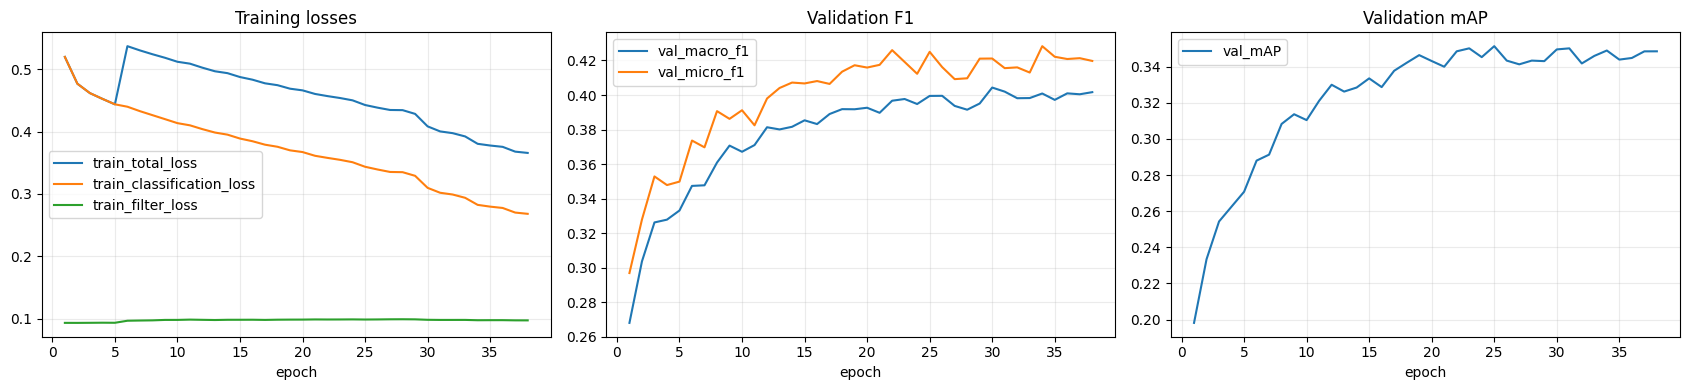

In [11]:
history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
history_df.plot(x="epoch", y=["train_total_loss", "train_classification_loss", "train_filter_loss"],
                ax=axes[0], title="Training losses")
history_df.plot(x="epoch", y=["val_macro_f1", "val_micro_f1"],
                ax=axes[1], title="Validation F1")
history_df.plot(x="epoch", y="val_mAP", ax=axes[2], title="Validation mAP")
for ax in axes:
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()


## 12. Đánh giá test tổng thể và theo từng lớp


In [12]:
checkpoint = torch.load(OUT_DIR / "best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model"])
thresholds = np.asarray(checkpoint["thresholds"])

test_y, test_prob, test_snr = predict(
    model, test_loader, DEVICE, CONFIG["input_mode"],
    sliding=CONFIG["sliding_window_eval"],
    hop_seconds=CONFIG["sliding_hop_seconds"],
)
test_pred = test_prob >= thresholds
overall = metrics(test_y, test_prob, thresholds)

print(f"Best epoch: {checkpoint['epoch']}")
display(pd.DataFrame([overall], index=["test"]))

precision, recall, f1, support = precision_recall_fscore_support(
    test_y, test_pred, average=None, zero_division=0
)
ap = [average_precision_score(test_y[:, i], test_prob[:, i])
      for i in range(len(CLASS_NAMES))]
per_class = pd.DataFrame({
    "label": CLASS_NAMES,
    "threshold": thresholds,
    "support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "AP": ap,
}).sort_values("f1", ascending=False)
display(per_class)
per_class.to_csv(OUT_DIR / "test_per_class.csv", index=False)


Best epoch: 30


,macro_f1,micro_f1,mAP
test,0.38189,0.41212,0.346999


,label,threshold,support,precision,recall,f1,AP
0,Music,0.40,889,0.542034,0.761530,0.633302,0.616967
9,Siren,0.70,200,0.615000,0.615000,0.615000,0.651940
1,Vehicle,0.50,525,0.438762,0.620952,0.514196,0.468138
15,Drum,0.50,164,0.459770,0.487805,0.473373,0.496987
8,Water,0.60,202,0.477528,0.420792,0.447368,0.392219
11,"Wind instrument, woodwind instrument",0.65,191,0.430693,0.455497,0.442748,0.450137
3,Animal,0.35,393,0.318741,0.592875,0.414591,0.364498
20,Percussion,0.30,142,0.312500,0.492958,0.382514,0.368151
18,Bowed string instrument,0.50,141,0.343023,0.418440,0.376997,0.333633
10,Fowl,0.45,201,0.387283,0.333333,0.358289,0.339284


## 13. Đánh giá theo SNR


,snr_band,samples,macro_f1,micro_f1,mAP
0,"[-5, 0] dB",1301,0.429198,0.458522,0.422500
1,"[5, 10] dB",1316,0.394517,0.417956,0.367835
2,"[15, 20] dB",1289,0.309157,0.354042,0.269713


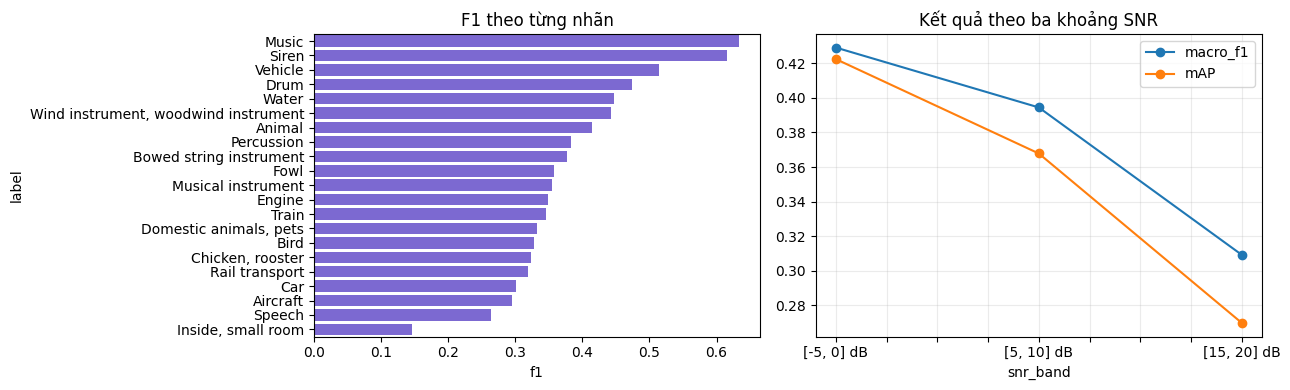

Đã lưu kết quả tại: /kaggle/working/runs/baseline_v3/filtered_3band_gating_pw-sqrt_gain_slide_pretrain_96538d25


In [13]:
snr_bands = [
    ("[-5, 0] dB", -5.0, 0.0),
    ("[5, 10] dB", 5.0, 10.0),
    ("[15, 20] dB", 15.0, 20.0),
]

snr_rows = []
for name, low, high in snr_bands:
    keep = (test_snr >= low) & (test_snr <= high)
    if not keep.any():
        print(f"Cảnh báo: không có mẫu trong band {name}")
        continue
    snr_rows.append({
        "snr_band": name,
        "samples": int(keep.sum()),
        **metrics(test_y[keep], test_prob[keep], thresholds),
    })
snr_df = pd.DataFrame(snr_rows)
display(snr_df)
snr_df.to_csv(OUT_DIR / "test_by_snr.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=per_class, x="f1", y="label", ax=axes[0], color="#7158e2")
axes[0].set_title("F1 theo từng nhãn")
snr_df.plot(x="snr_band", y=["macro_f1", "mAP"], marker="o", ax=axes[1])
axes[1].set_title("Kết quả theo ba khoảng SNR"); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

result = {"overall": overall, "by_snr": snr_rows}
(OUT_DIR / "test_metrics.json").write_text(json.dumps(result, indent=2), encoding="utf8")
print("Đã lưu kết quả tại:", OUT_DIR)


## 14. Minh họa kết quả FILTER và dự đoán một mẫu


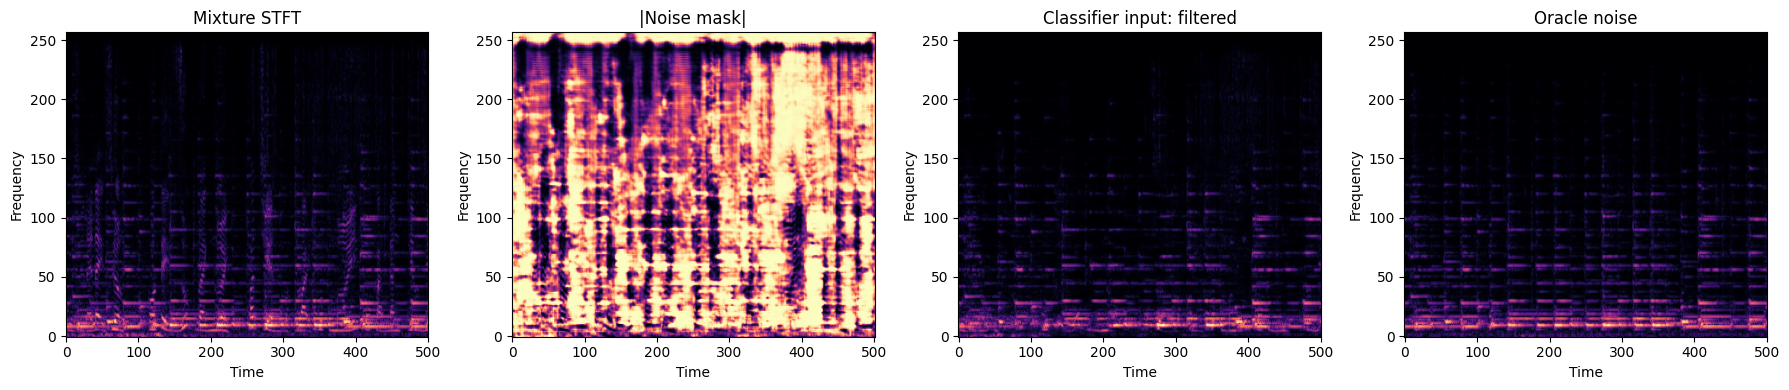

SNR: -5.0 dB
Nhãn thật: ['Music', 'Musical instrument']
Dự đoán : ['Music', 'Musical instrument']
Cross-band gate [low, mid, high]: [0.3234812  0.00132215 0.67519665]


In [14]:
sample_mix, sample_noise, sample_target, sample_snr = test_ds[0]
with torch.no_grad():
    sample_logits, estimated, sample_mask, sample_gate = model(
        sample_mix.unsqueeze(0).to(DEVICE),
        sample_noise.unsqueeze(0).to(DEVICE),
        CONFIG["input_mode"],
    )
prob = sample_logits.sigmoid()[0].cpu().numpy()
pred_names = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) if prob[i] >= thresholds[i]]
true_names = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) if sample_target[i] > 0]

mix_spec = model.stft(sample_mix.unsqueeze(0).to(DEVICE))[0].abs().log1p().cpu()
oracle_spec = model.stft(sample_noise.unsqueeze(0).to(DEVICE))[0].abs().log1p().cpu()
estimated_mag = estimated[0].abs().log1p().cpu()
mask_mag = (sample_mask[0].abs().cpu() if sample_mask is not None
            else torch.zeros_like(estimated_mag))
mask_title = "|Noise mask|" if sample_mask is not None else "Mask not used"

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, image_data, title in zip(
    axes,
    [mix_spec, mask_mag, estimated_mag, oracle_spec],
    ["Mixture STFT", mask_title, f"Classifier input: {CONFIG['input_mode']}", "Oracle noise"],
):
    ax.imshow(image_data.numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title); ax.set_xlabel("Time"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

print("SNR:", sample_snr, "dB")
print("Nhãn thật:", true_names)
print("Dự đoán :", pred_names)
print("Cross-band gate [low, mid, high]:", sample_gate[0].cpu().numpy())
